# Catalog fNL validation walkthrough

This notebook validates the catalog-level local PNG / fNL blinding path added to `desiblind` and wired through `desi-clustering`.

The reference convention used here is the integrated LSS main-script blinding path (`LSS/scripts/main/apply_blinding_main_fromfile_fcomp.py`). In code terms the physics operation is:

```python
mockfactory.blinding.CutskyCatalogBlinding.png(
    ..., method='data_weights', shotnoise_correction=True
)
```

The fNL factor is kept internal: it is folded into `WEIGHT` and `WEIGHT_COMP`, and the final LSS-like random resampling / nbar / FKP rebuild makes the saved catalogs normal measurement inputs. No blinding-specific weight-ratio column is written.


## Validation ladder

1. Check that this notebook is using the local fNL worktrees and the MPI-enabled `pyrecon` module required by `mockfactory`.
2. Run the direct LSS-core comparison: `CatalogFNLBlinder` vs the raw `CutskyCatalogBlinding.png(..., method='data_weights', shotnoise_correction=True)` call.
3. Check fNL-only saved-catalog outputs from the `desi-clustering` driver.
4. Check the combined `BAO+RSD+fNL` saved-catalog outputs and diagnostics.
5. Read the measured Pk/xi statistics for `unblinded`, `BAO-only`, `BAO+RSD`, and `BAO+RSD+fNL`, then display blind-vs-unblind comparison plots.


In [1]:
from pathlib import Path
import json
import os
import subprocess
import sys

import numpy as np
import pandas as pd
from IPython.display import Image, display, Markdown

DESIBLIND = Path('/global/homes/u/uendert/repos/desi/desiblind-catalog-fnl')
DESI_CLUSTERING = Path('/global/homes/u/uendert/repos/desi/desi-clustering-catalog-fnl')
for repo in [DESIBLIND, DESI_CLUSTERING]:
    if str(repo) not in sys.path:
        sys.path.insert(0, str(repo))

import desiblind
from desiblind import CatalogFNLBlinder
import pyrecon

print('desiblind:', desiblind.__file__)
print('CatalogFNLBlinder:', CatalogFNLBlinder)
print('pyrecon:', pyrecon.__file__)
assert str(DESIBLIND) in desiblind.__file__
assert '/pyrecon/mpi/' in pyrecon.__file__, 'fNL mockfactory validation requires pyrecon/mpi from the cosmodesi module environment'


desiblind: /global/homes/u/uendert/repos/desi/desiblind-catalog-fnl/desiblind/__init__.py
CatalogFNLBlinder: <class 'desiblind.catalog_fnl.CatalogFNLBlinder'>
pyrecon: /global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20260321-1.0.0/code/pyrecon/mpi/lib/python3.12/site-packages/pyrecon/__init__.py


## 1. LSS-core fNL operation

This is the narrowest validation. It compares two implementations of the same operation on the same synthetic cutsky catalogs:

- direct LSS-style core call to `CutskyCatalogBlinding.png(..., method='data_weights', shotnoise_correction=True)`
- `desiblind.CatalogFNLBlinder.apply_blinding(...)`

The compared quantities are:

```text
new WEIGHT
new WEIGHT_COMP
internal fNL factor = new WEIGHT / old WEIGHT
```

This does not test final random resampling or clustering statistics; those are later steps.


In [2]:
CORE_OUTPUT = Path('/pscratch/sd/u/uendert/desiblind_catalog_fnl_notebook_validation/core_lss_summary.json')
CORE_OUTPUT.parent.mkdir(parents=True, exist_ok=True)
cmd = [
    sys.executable,
    str(DESIBLIND / 'scripts' / 'validation' / 'validate_catalog_fnl_lss_core.py'),
    '--output', str(CORE_OUTPUT),
]
print('running:', ' '.join(cmd))
completed = subprocess.run(cmd, check=True, text=True, capture_output=True)
print(completed.stdout)
core_summary = json.loads(CORE_OUTPUT.read_text())
assert core_summary['passed'] is True
pd.DataFrame([core_summary])[[
    'passed', 'max_abs_delta_weight', 'max_abs_delta_weight_comp', 'max_abs_delta_factor',
    'factor_min', 'factor_mean', 'factor_max', 'ndata', 'nrandom', 'nmesh'
]]


running: /global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20260321-1.0.0/conda/bin/python /global/homes/u/uendert/repos/desi/desiblind-catalog-fnl/scripts/validation/validate_catalog_fnl_lss_core.py --output /pscratch/sd/u/uendert/desiblind_catalog_fnl_notebook_validation/core_lss_summary.json


{
  "factor_max": 1.0001527048437049,
  "factor_mean": 1.0000492023639,
  "factor_min": 0.9999263437427772,
  "max_abs_delta_factor": 0.0,
  "max_abs_delta_weight": 0.0,
  "max_abs_delta_weight_comp": 0.0,
  "ndata": 80,
  "nmesh": 16,
  "nrandom": 400,
  "parameters": {
    "bias": 2.0,
    "fnl": 5.0,
    "zeff": 0.8
  },
  "passed": true,
  "seed": 42
}



,passed,max_abs_delta_weight,max_abs_delta_weight_comp,max_abs_delta_factor,factor_min,factor_mean,factor_max,ndata,nrandom,nmesh
0,True,0.0,0.0,0.0,0.999926,1.000049,1.000153,80,400,16


## 2. fNL-only saved-catalog driver smoke

This checks the `desi-clustering` saved-catalog driver for fNL-only mode on a fresh full end-to-end LRG NGC nran=2 validation sample.

Expected behavior:

```text
modes = fnl
final randoms are resampled from the final fNL-blinded data
no blinding-specific weight-ratio column is written
NX and WEIGHT_FKP are present after the final nbar/FKP rebuild
```


In [3]:
FNL_ONLY_ROOT = Path('/pscratch/sd/u/uendert/desi_clustering_catalog_fnl_lrg_subset_20260706_211740')
fnl_only_summary = json.loads((FNL_ONLY_ROOT / 'fnl_only' / 'catalogs' / 'summary.json').read_text())
fnl_only_diag = json.loads((FNL_ONLY_ROOT / 'fnl_only' / 'diagnostics' / 'LRG_NGC_fnl_subset_diagnostics.json').read_text())

rows = [{
    'root': str(FNL_ONLY_ROOT),
    'modes': ','.join(fnl_only_summary['modes']),
    'rows': fnl_only_summary['rows'],
    'random_rows_total': fnl_only_summary['random_rows_total'],
    'final_random_resampled': fnl_only_summary['lss_like_catalogs']['final_random_resampled'],
    'fnl': fnl_only_summary['applied'][0]['parameters']['fnl'],
    'fnl_factor_min': fnl_only_diag['weights']['internal_fnl_weight_factor']['min'],
    'fnl_factor_mean': fnl_only_diag['weights']['internal_fnl_weight_factor']['mean'],
    'fnl_factor_max': fnl_only_diag['weights']['internal_fnl_weight_factor']['max'],
}]
pd.DataFrame(rows)


,root,modes,rows,random_rows_total,final_random_resampled,fnl,fnl_factor_min,fnl_factor_mean,fnl_factor_max
0,/pscratch/sd/u/uendert/desi_clustering_catalog...,fnl,2000,20000,True,5.0,0.991756,0.997059,1.002852


In [4]:
import fitsio
fnl_data = fitsio.read(FNL_ONLY_ROOT / 'fnl_only' / 'catalogs' / 'LRG_NGC_z0.4-1.1_fnl-only_clustering.dat.fits', ext='LSS')
fnl_random = fitsio.read(FNL_ONLY_ROOT / 'fnl_only' / 'catalogs' / 'LRG_NGC_z0.4-1.1_fnl-only_0_clustering.ran.fits', ext='LSS')
checks = pd.DataFrame([
    {'catalog': 'data', 'rows': len(fnl_data), 'has_blinding_specific_column': any('BLIND' in name.upper() for name in fnl_data.dtype.names), 'has_NX': 'NX' in fnl_data.dtype.names, 'has_WEIGHT_FKP': 'WEIGHT_FKP' in fnl_data.dtype.names},
    {'catalog': 'random', 'rows': len(fnl_random), 'has_blinding_specific_column': any('BLIND' in name.upper() for name in fnl_random.dtype.names), 'has_NX': 'NX' in fnl_random.dtype.names, 'has_WEIGHT_FKP': 'WEIGHT_FKP' in fnl_random.dtype.names},
])
assert not checks['has_blinding_specific_column'].any()
assert checks['has_NX'].all()
assert checks['has_WEIGHT_FKP'].all()
checks


,catalog,rows,has_blinding_specific_column,has_NX,has_WEIGHT_FKP
0,data,2000,False,True,True
1,random,20000,False,True,True


### fNL-only saved-catalog diagnostics

The weight diagnostic includes the internal fNL factor. The factor is diagnostic-only and is not written as a persistent catalog column.


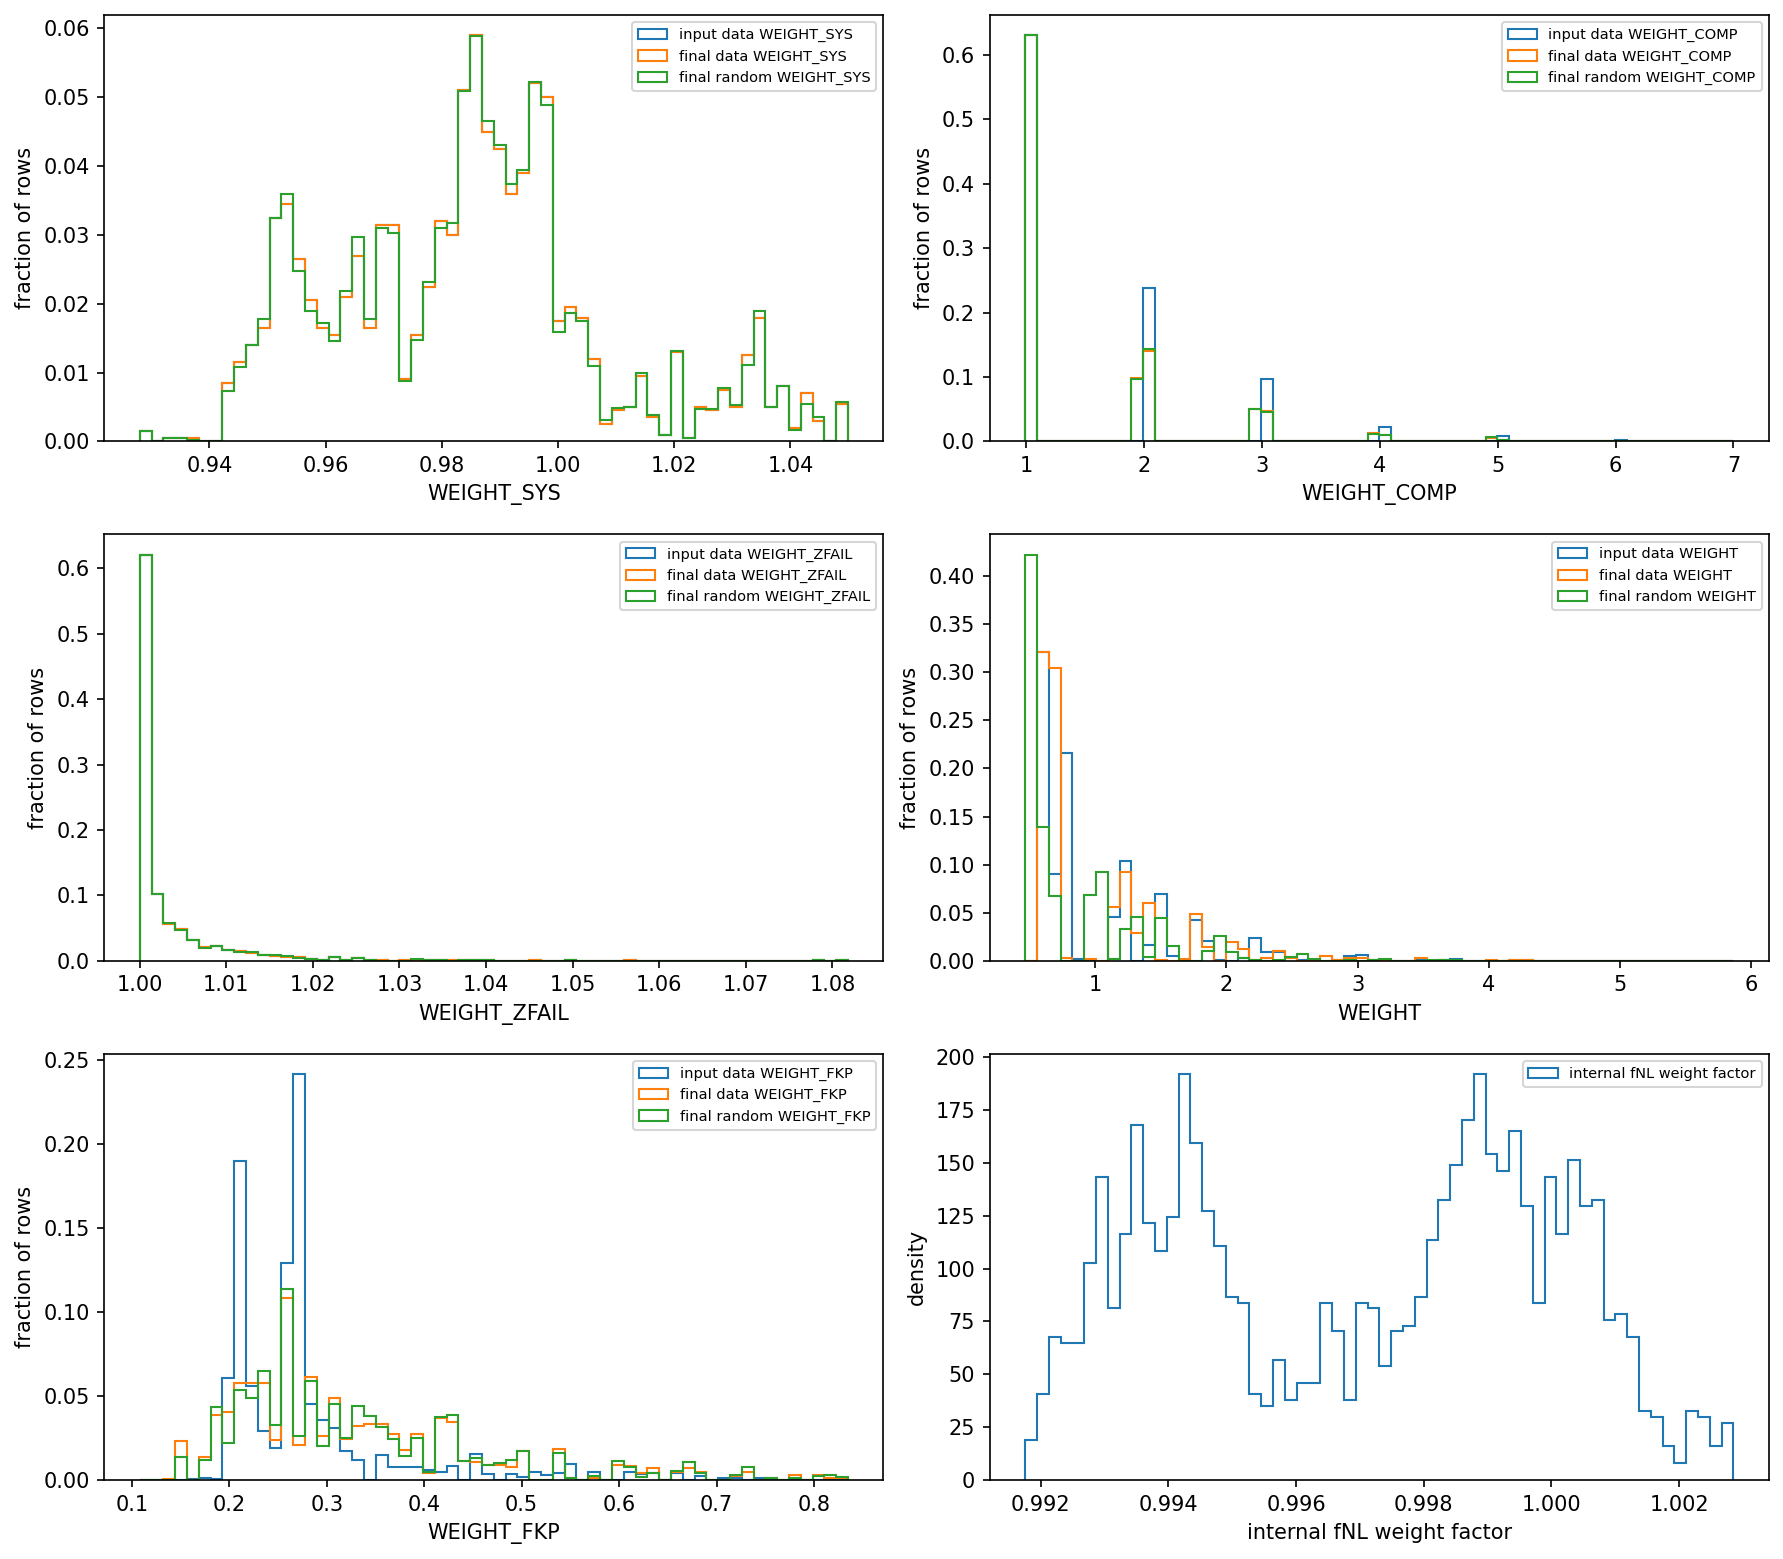

In [5]:
display(Image(filename=str(FNL_ONLY_ROOT / 'fnl_only' / 'diagnostics' / 'LRG_NGC_fnl_subset_weight_diagnostics.png')))


## 3. Combined BAO+RSD+fNL saved-catalog validation

This checks the full current catalog-level ordering on a full-row LRG NGC nran=2 sample:

```text
BAO/AP redshift remapping
-> internal BAO n(z) reweighting
-> reconstruction random resampling
-> RSD redshift blinding using pyrecon realspace catalog
-> fNL data-weight blinding
-> final random resampling from final data
-> final nbar / NX / WEIGHT / WEIGHT_FKP rebuild
```


In [6]:
COMBINED_ROOT = Path('/pscratch/sd/u/uendert/desi_catalog_blinding_fnl_endtoend_lrg_dr1_v1p5_nran2_z0p6_0p8')
combined_summary = json.loads((COMBINED_ROOT / 'bao_rsd_fnl' / 'catalogs' / 'summary.json').read_text())
combined_diag = json.loads((COMBINED_ROOT / 'bao_rsd_fnl' / 'diagnostics' / 'LRG_NGC_z0.4-1.1_bao_rsd_fnl_full_endtoend_nran2_diagnostics.json').read_text())

applied = {entry['mode']: entry['parameters'] for entry in combined_summary.get('applied', [])}
fnl_parameters = combined_summary.get('parameters_fnl', applied.get('fnl', {}))
lss_like = combined_summary.get('lss_like_catalogs', {})
combined_rows = [{
    'root': str(COMBINED_ROOT),
    'modes': ','.join(combined_summary.get('modes', [entry['mode'] for entry in combined_summary.get('applied', [])])),
    'applied_order': ','.join(entry['mode'] for entry in combined_summary.get('applied', [])),
    'rows': combined_summary['rows'],
    'random_rows_total': combined_summary['random_rows_total'],
    'final_random_resampled': combined_summary.get('final_random_resampled', lss_like.get('final_random_resampled')),
    'final_nbar_fkp': combined_summary.get('final_nbar_fkp', lss_like.get('final_nbar_fkp')),
    'fnl': fnl_parameters['fnl'],
    'shotnoise_correction': fnl_parameters['shotnoise_correction'],
    'method': fnl_parameters['method'],
}]
pd.DataFrame(combined_rows)


,root,modes,applied_order,rows,random_rows_total,final_random_resampled,final_nbar_fkp,fnl,shotnoise_correction,method
0,/pscratch/sd/u/uendert/desi_catalog_blinding_f...,"bao,rsd,fnl","bao,rsd,fnl",1476135,18774199,True,True,5.0,True,data_weights


In [7]:
combined_data = fitsio.read(COMBINED_ROOT / 'bao_rsd_fnl' / 'catalogs' / 'LRG_NGC_z0.4-1.1_bao-rsd-fnl_clustering.dat.fits', ext='LSS')
combined_random = fitsio.read(COMBINED_ROOT / 'bao_rsd_fnl' / 'catalogs' / 'LRG_NGC_z0.4-1.1_bao-rsd-fnl_0_clustering.ran.fits', ext='LSS')
combined_checks = pd.DataFrame([
    {'catalog': 'data', 'rows': len(combined_data), 'has_blinding_specific_column': any('BLIND' in name.upper() for name in combined_data.dtype.names), 'has_NX': 'NX' in combined_data.dtype.names, 'has_WEIGHT_FKP': 'WEIGHT_FKP' in combined_data.dtype.names},
    {'catalog': 'random', 'rows': len(combined_random), 'has_blinding_specific_column': any('BLIND' in name.upper() for name in combined_random.dtype.names), 'has_NX': 'NX' in combined_random.dtype.names, 'has_WEIGHT_FKP': 'WEIGHT_FKP' in combined_random.dtype.names},
])
assert not combined_checks['has_blinding_specific_column'].any()
assert combined_checks['has_NX'].all()
assert combined_checks['has_WEIGHT_FKP'].all()
combined_checks


,catalog,rows,has_blinding_specific_column,has_NX,has_WEIGHT_FKP
0,data,1476135,False,True,True
1,random,9389588,False,True,True


### Combined catalog diagnostics

These are catalog-level diagnostics, not Pk/xi. They show redshift evolution, random matching, and weight-column behavior through the saved-catalog workflow.


internal_bao_nz_factor


,max,mean,median,min,p01,p05,p95,p99,std
0,1.282821,0.996241,0.979175,0.91786,0.91786,0.926601,1.15716,1.19597,0.065797


internal_fnl_weight_factor


,max,mean,median,min,p01,p05,p95,p99,std
0,1.004854,0.998741,0.998759,0.992505,0.994861,0.995601,1.002031,1.003289,0.001981


**LRG_NGC_z0.4-1.1_bao_rsd_fnl_full_endtoend_nran2_data_redshift_steps.png**

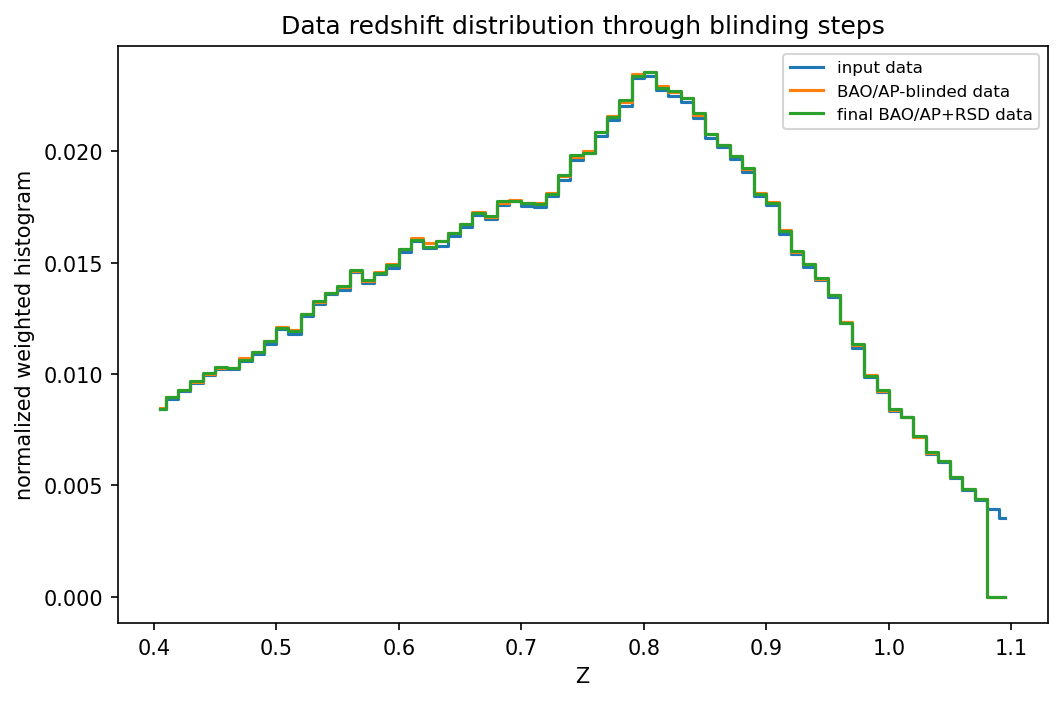

**LRG_NGC_z0.4-1.1_bao_rsd_fnl_full_endtoend_nran2_random_matching.png**

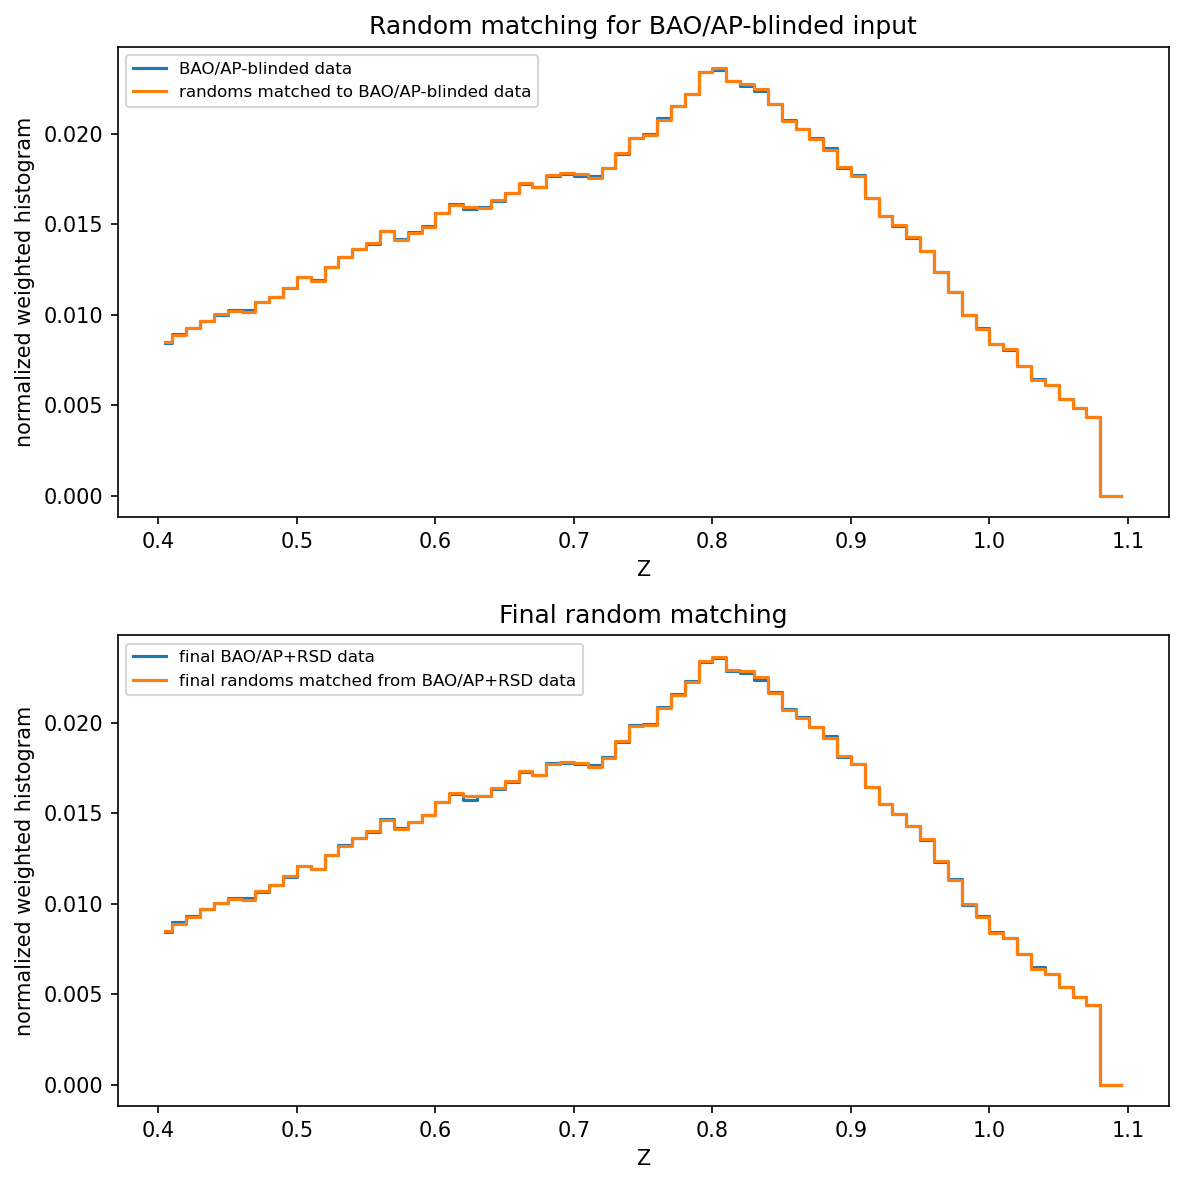

**LRG_NGC_z0.4-1.1_bao_rsd_fnl_full_endtoend_nran2_weight_diagnostics.png**

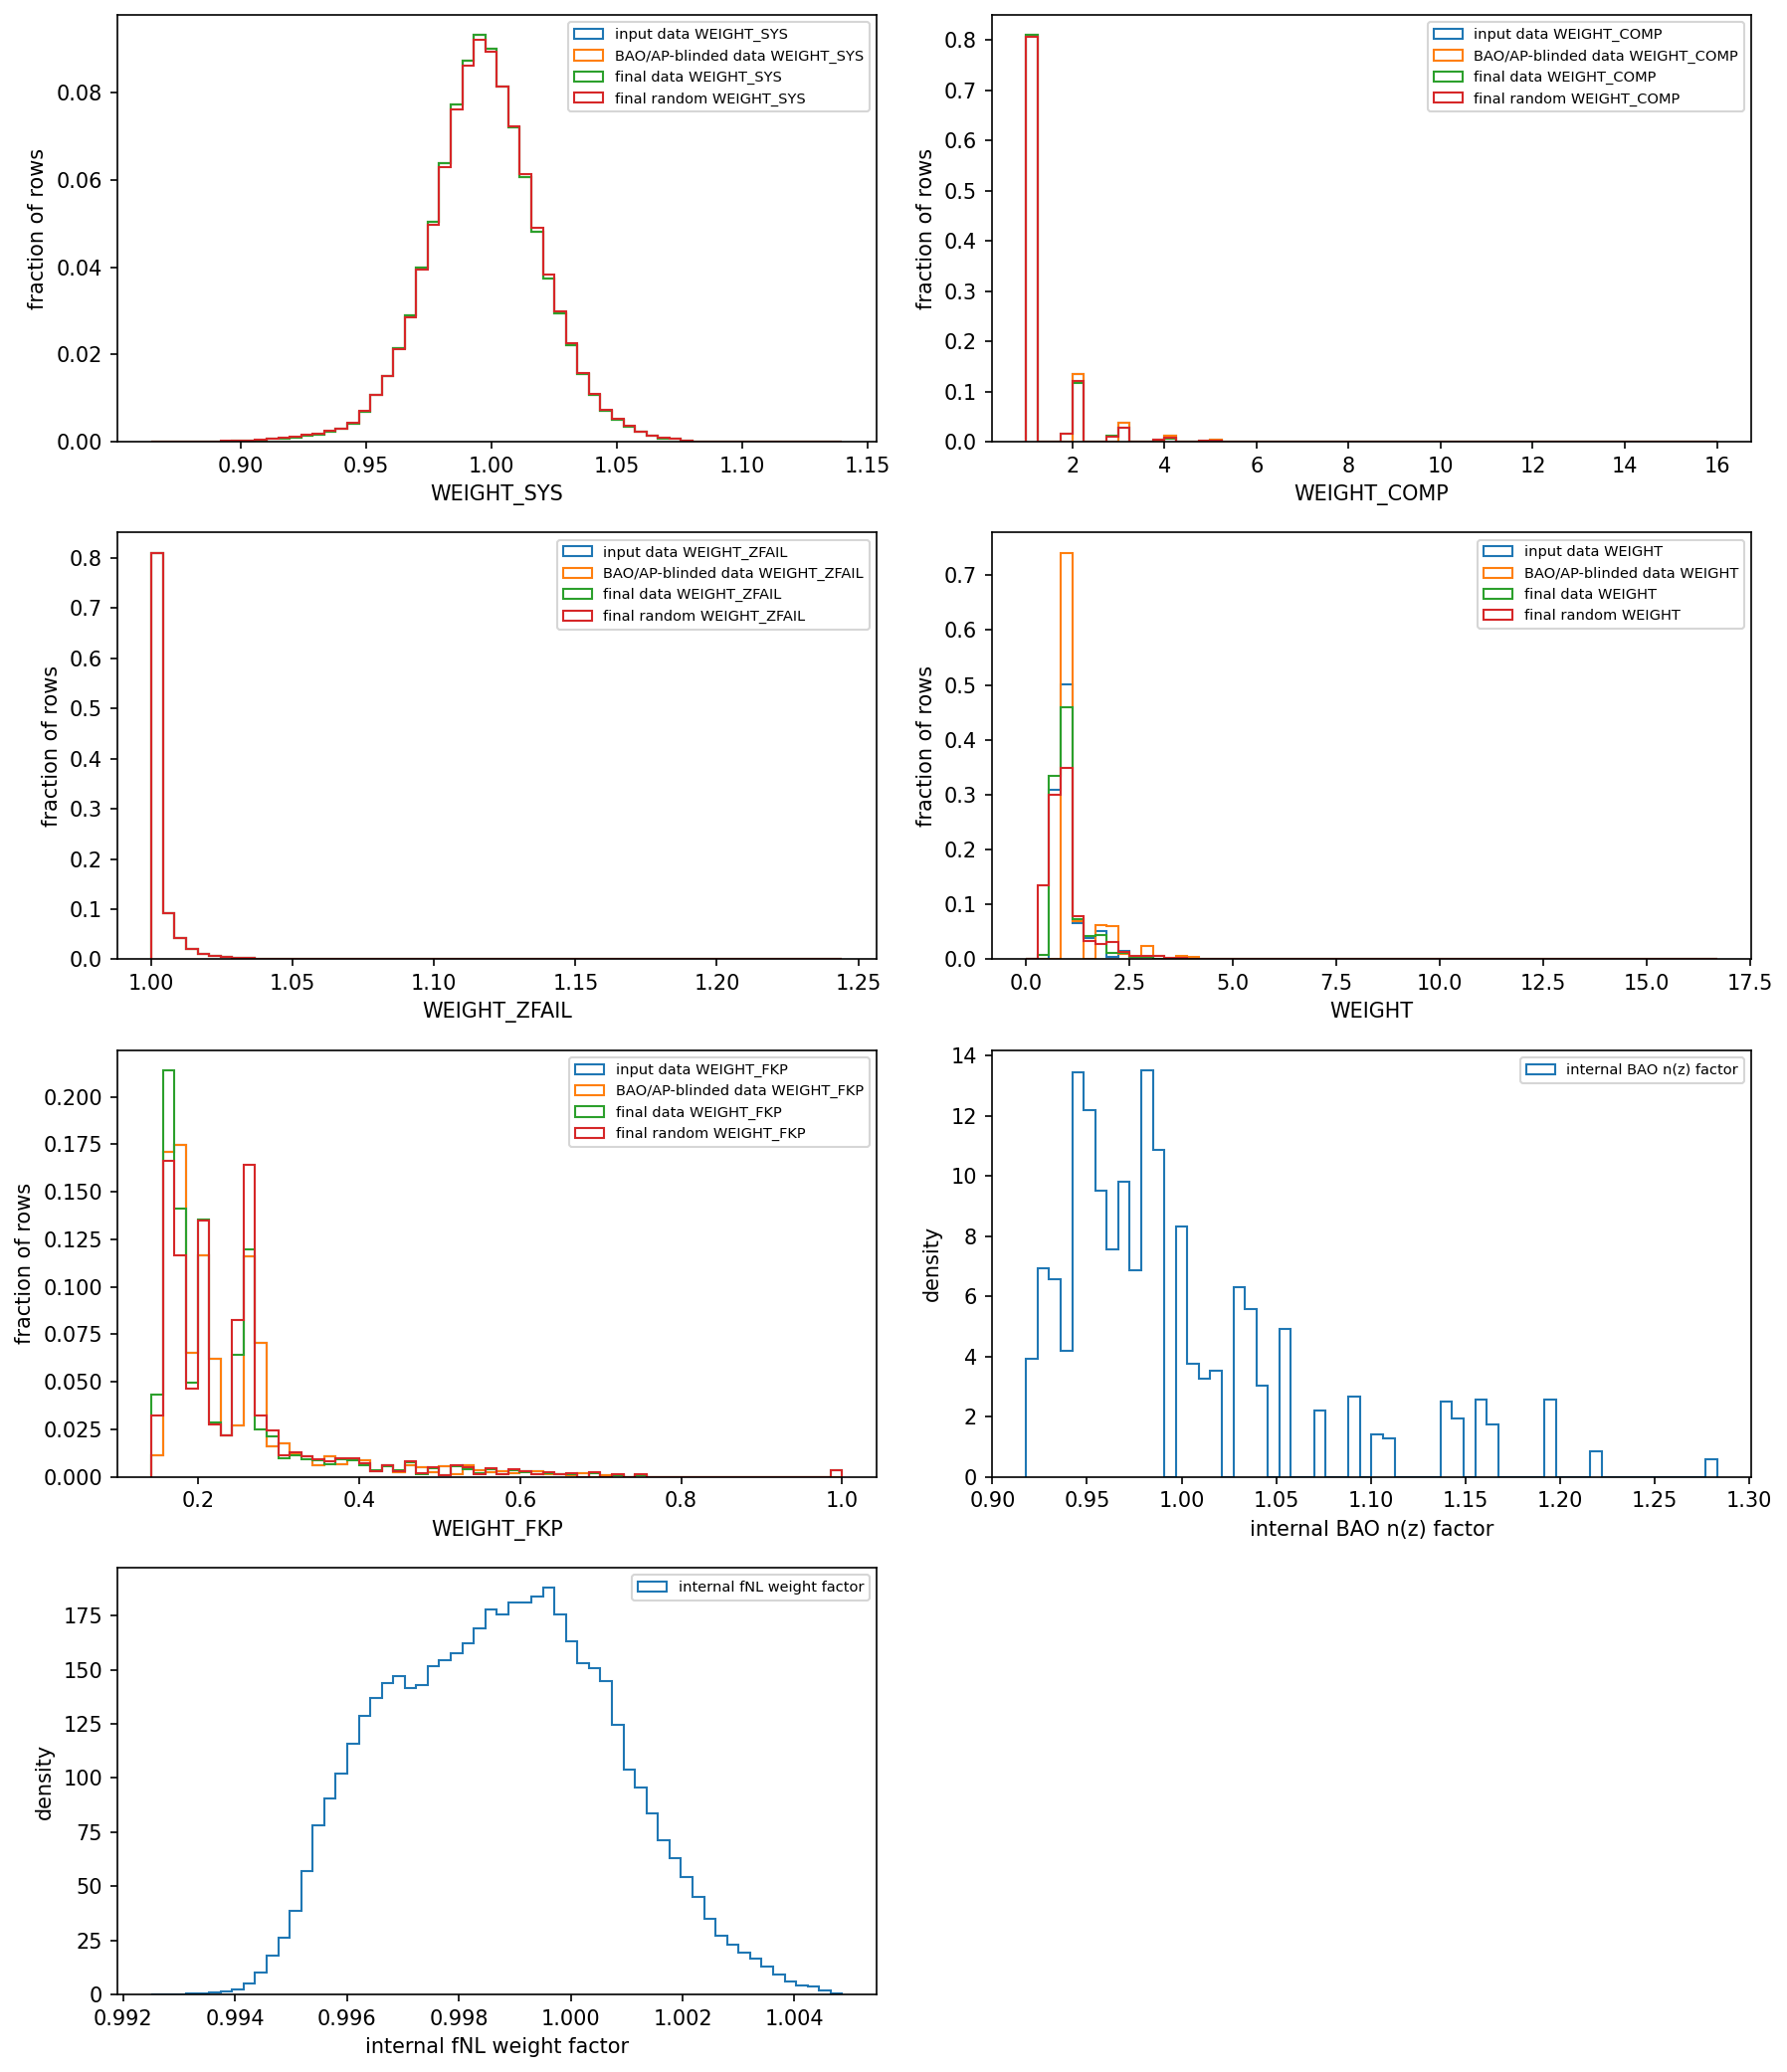

In [8]:
for key in ['internal_bao_nz_factor', 'internal_fnl_weight_factor']:
    print(key)
    display(pd.DataFrame([combined_diag['weights'][key]]))

for name in [
    'LRG_NGC_z0.4-1.1_bao_rsd_fnl_full_endtoend_nran2_data_redshift_steps.png',
    'LRG_NGC_z0.4-1.1_bao_rsd_fnl_full_endtoend_nran2_random_matching.png',
    'LRG_NGC_z0.4-1.1_bao_rsd_fnl_full_endtoend_nran2_weight_diagnostics.png',
]:
    display(Markdown(f'**{name}**'))
    display(Image(filename=str(COMBINED_ROOT / 'bao_rsd_fnl' / 'diagnostics' / name)))


## 4. Clustering-statistic validation

The saved-catalog diagnostics above are not enough by themselves. This section reads the actual `desi-clustering` measurements for four matched saved-catalog states:

```text
matched unblinded reference
BAO-only
BAO+RSD
BAO+RSD+fNL
```

Both Pk and xi were measured through `compute_stats_from_options` / `desi-clustering`, and the plots below were made from `lsstypes` objects.


In [9]:
import lsstypes as types

MEASUREMENT_SUMMARY = json.loads((COMBINED_ROOT / 'measurement_summary.json').read_text())
measurement_df = pd.DataFrame(MEASUREMENT_SUMMARY)
measurement_df


,label,version,stats_dir,catalog_dir
0,unblinded reference,full-endtoend-unblinded-reference,/pscratch/sd/u/uendert/desi_catalog_blinding_f...,/pscratch/sd/u/uendert/desi_catalog_blinding_f...
1,BAO-only,full-endtoend-bao,/pscratch/sd/u/uendert/desi_catalog_blinding_f...,/pscratch/sd/u/uendert/desi_catalog_blinding_f...
2,BAO+RSD,full-endtoend-bao-rsd,/pscratch/sd/u/uendert/desi_catalog_blinding_f...,/pscratch/sd/u/uendert/desi_catalog_blinding_f...
3,BAO+RSD+fNL,full-endtoend-bao-rsd-fnl,/pscratch/sd/u/uendert/desi_catalog_blinding_f...,/pscratch/sd/u/uendert/desi_catalog_blinding_f...


In [10]:
def stat_filename(kind, zrange=(0.6, 0.8)):
    z = f'z{zrange[0]:.1f}-{zrange[1]:.1f}'
    stem = 'mesh2_spectrum_poles' if kind == 'pk' else 'particle2_correlation_smu'
    return f'{stem}_LRG_{z}_NGC_weight-default-FKP.h5'

stat_rows = []
for row in MEASUREMENT_SUMMARY:
    stats_dir = Path(row['stats_dir'])
    for kind in ['pk', 'xi']:
        fn = stats_dir / stat_filename(kind)
        obj = types.read(fn)
        stat_rows.append({'label': row['label'], 'kind': kind, 'file': str(fn), 'object': type(obj).__name__, 'exists': fn.exists()})
stat_df = pd.DataFrame(stat_rows)
assert stat_df['exists'].all()
stat_df[['label', 'kind', 'object', 'file']]


,label,kind,object,file
0,unblinded reference,pk,Mesh2SpectrumPoles,/pscratch/sd/u/uendert/desi_catalog_blinding_f...
1,unblinded reference,xi,Count2Correlation,/pscratch/sd/u/uendert/desi_catalog_blinding_f...
2,BAO-only,pk,Mesh2SpectrumPoles,/pscratch/sd/u/uendert/desi_catalog_blinding_f...
3,BAO-only,xi,Count2Correlation,/pscratch/sd/u/uendert/desi_catalog_blinding_f...
4,BAO+RSD,pk,Mesh2SpectrumPoles,/pscratch/sd/u/uendert/desi_catalog_blinding_f...
5,BAO+RSD,xi,Count2Correlation,/pscratch/sd/u/uendert/desi_catalog_blinding_f...
6,BAO+RSD+fNL,pk,Mesh2SpectrumPoles,/pscratch/sd/u/uendert/desi_catalog_blinding_f...
7,BAO+RSD+fNL,xi,Count2Correlation,/pscratch/sd/u/uendert/desi_catalog_blinding_f...


### Blind-vs-unblind clustering comparisons

The plots below show the matched unblinded reference against BAO-only, BAO+RSD, and BAO+RSD+fNL, followed by all four states together.


**mesh2_spectrum_unblind_vs_bao_only_z0.6-0.8.png**

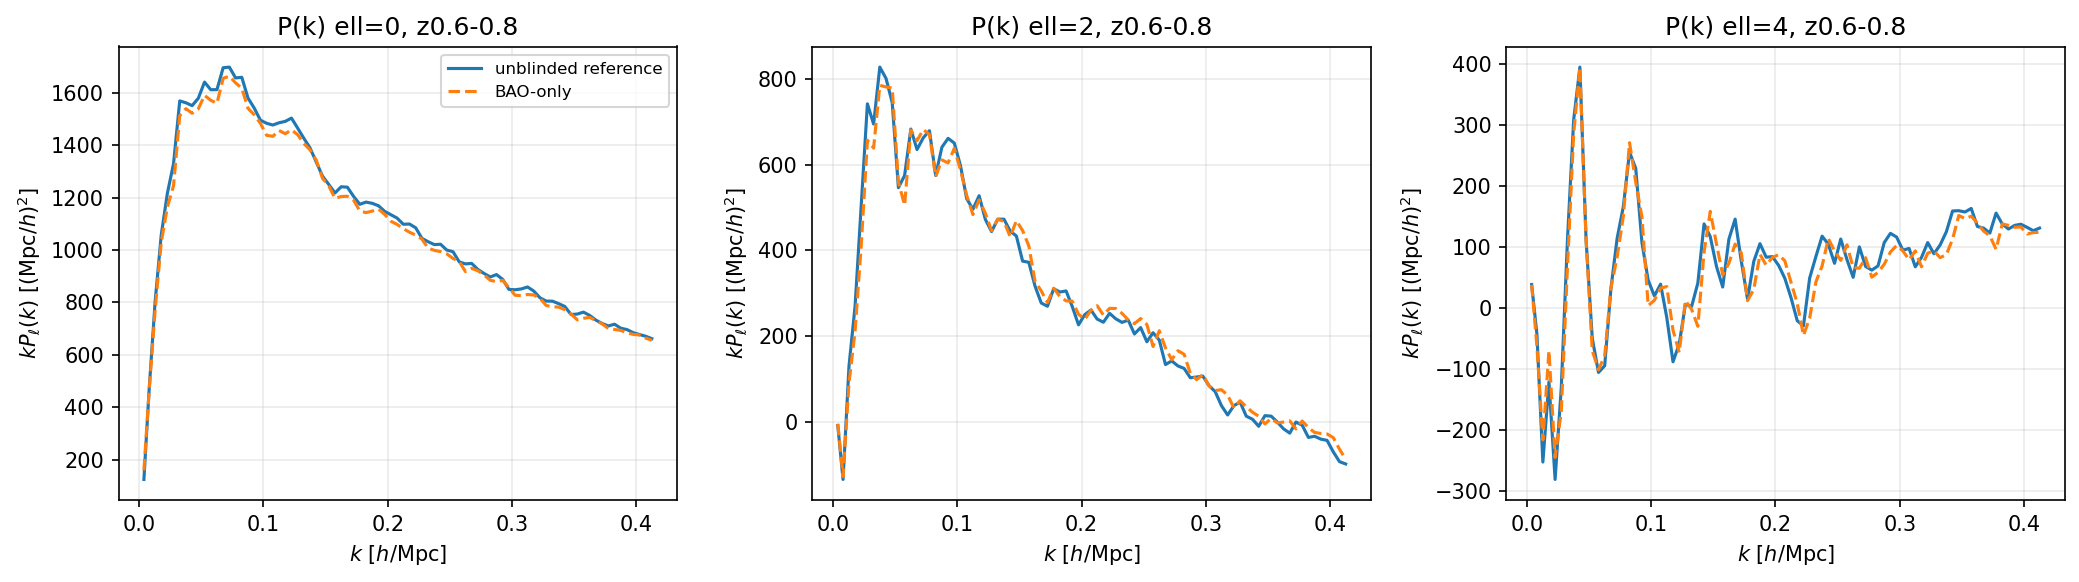

**particle2_correlation_unblind_vs_bao_only_z0.6-0.8.png**

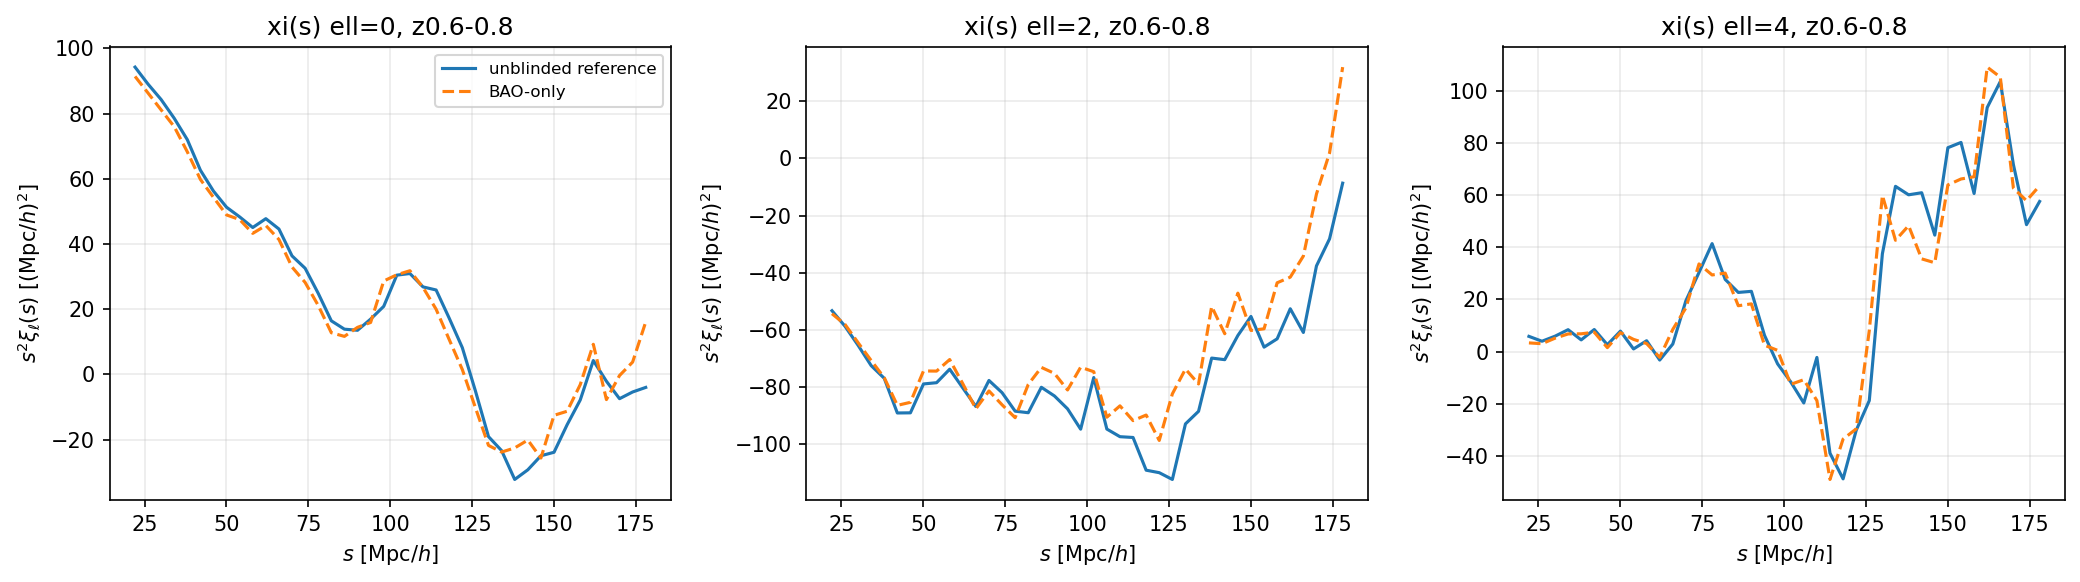

**mesh2_spectrum_unblind_vs_bao_rsd_z0.6-0.8.png**

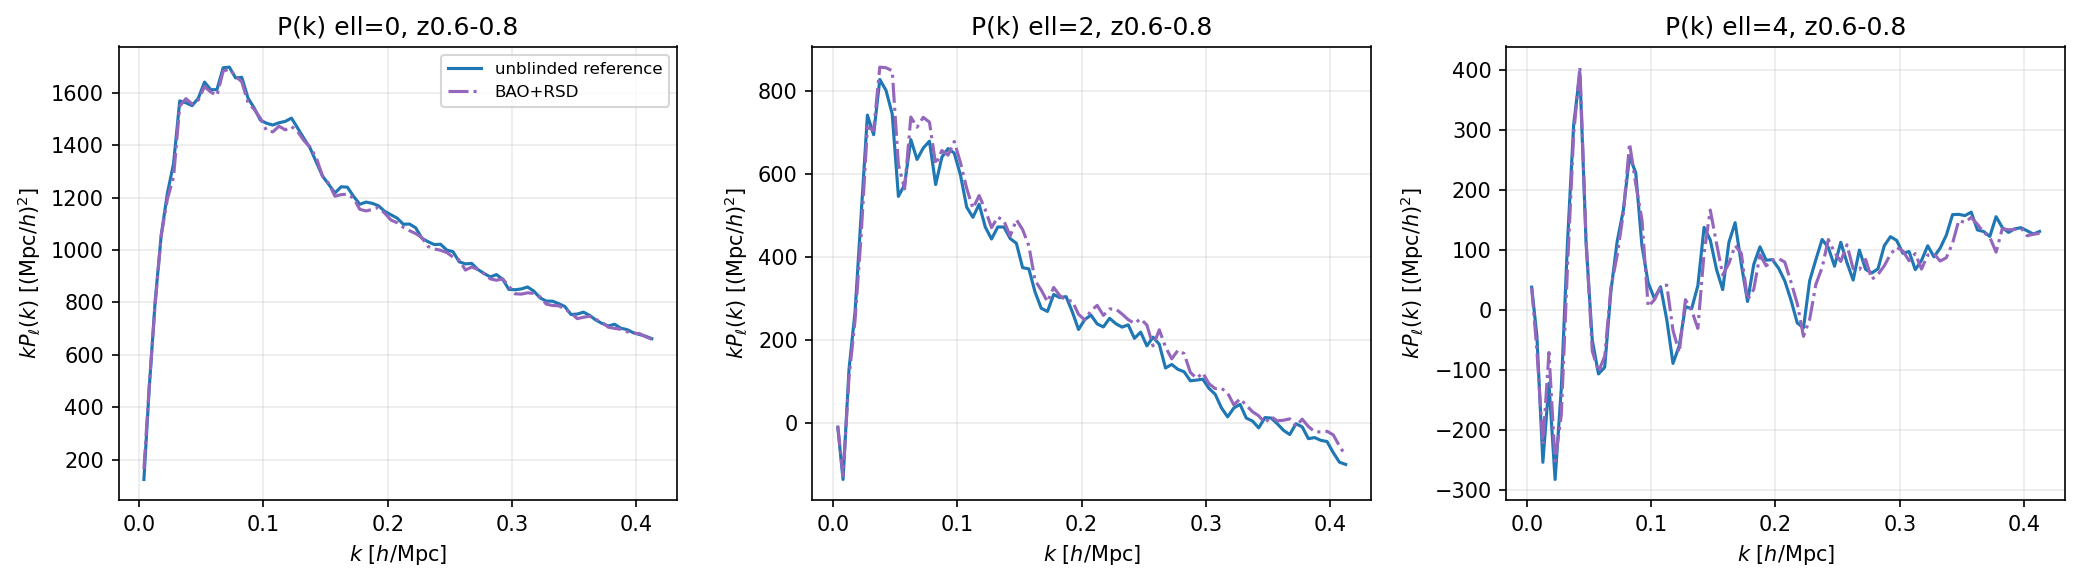

**particle2_correlation_unblind_vs_bao_rsd_z0.6-0.8.png**

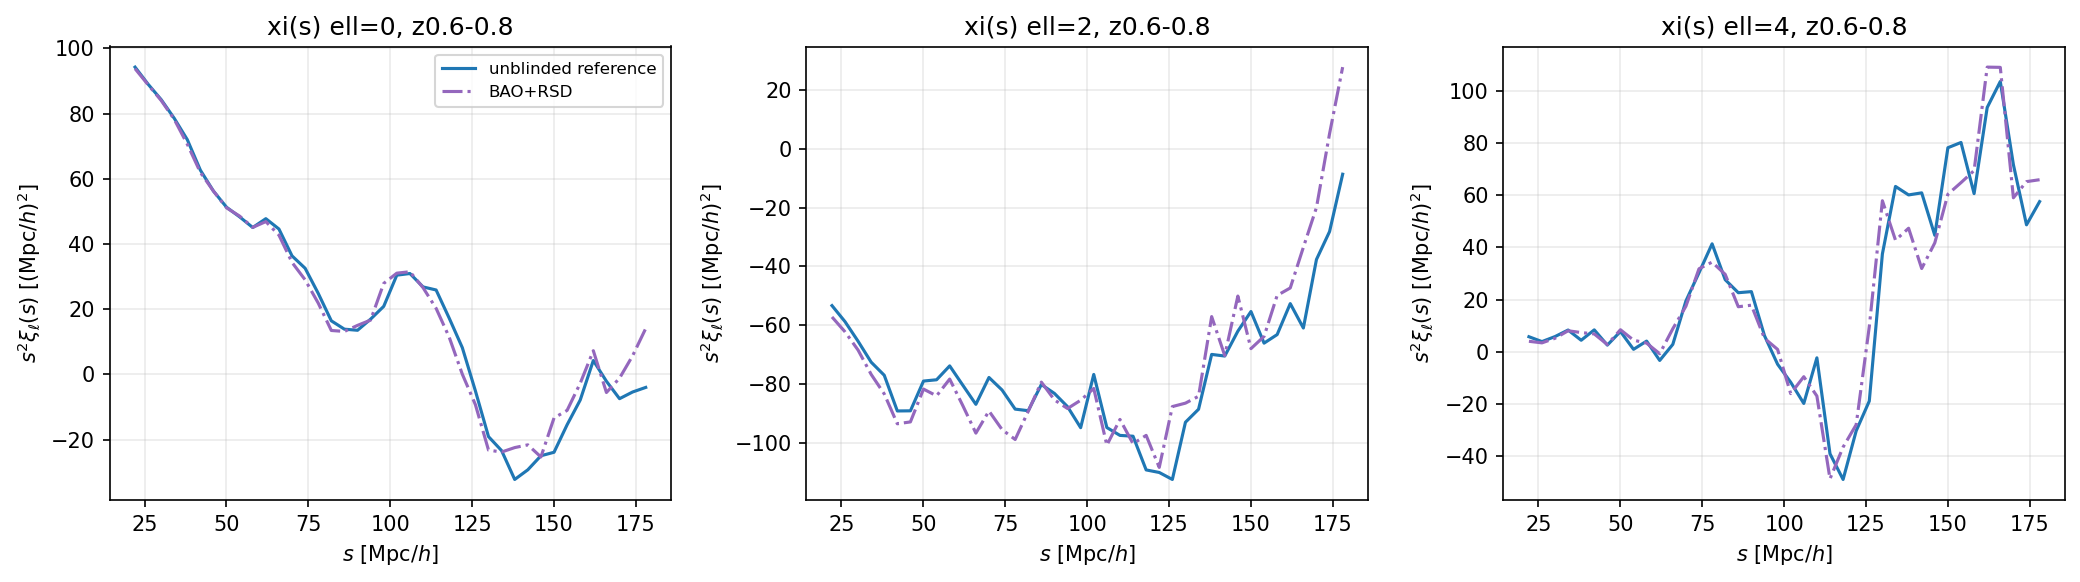

**mesh2_spectrum_unblind_vs_bao_rsd_fnl_z0.6-0.8.png**

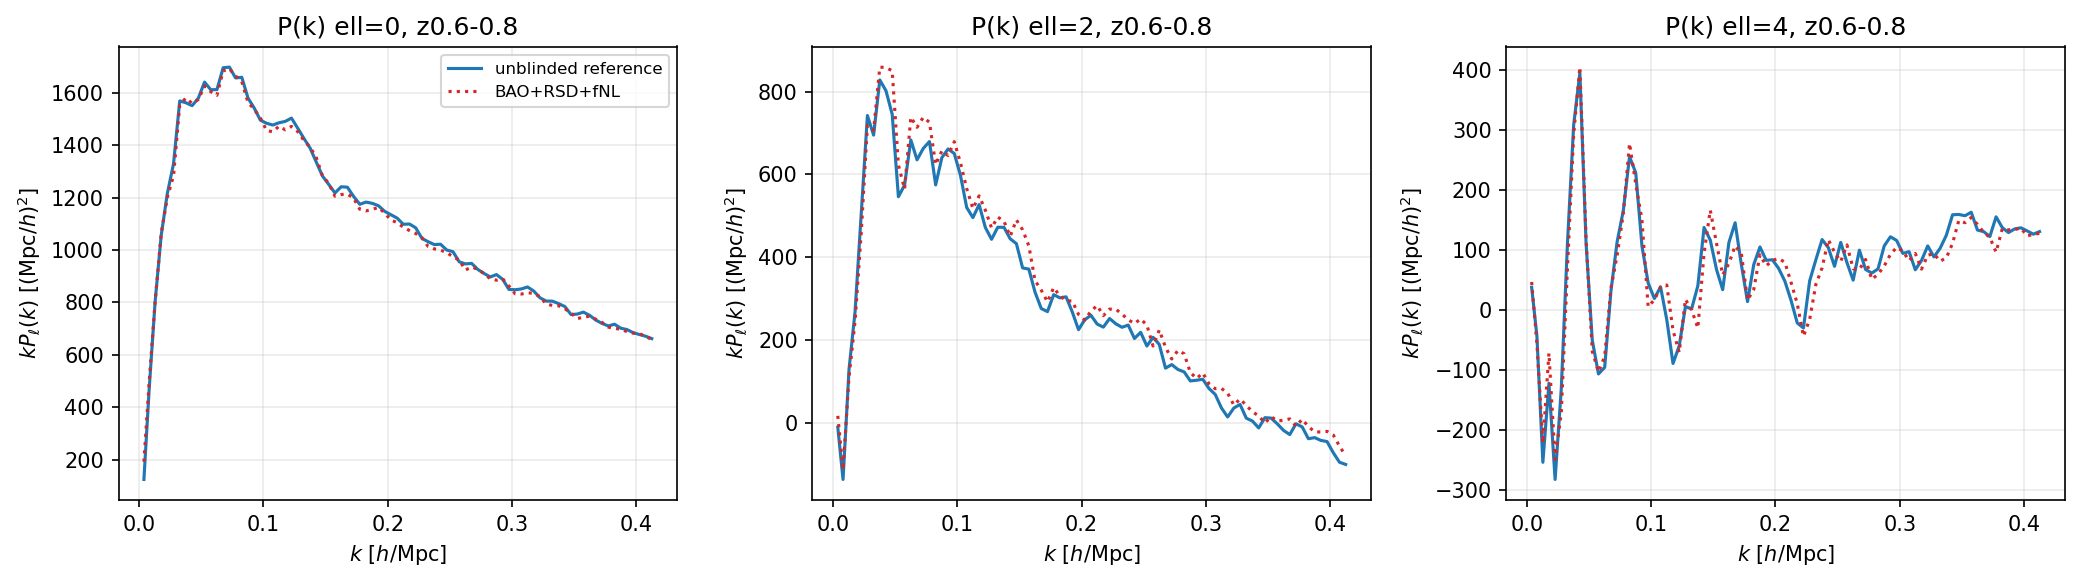

**particle2_correlation_unblind_vs_bao_rsd_fnl_z0.6-0.8.png**

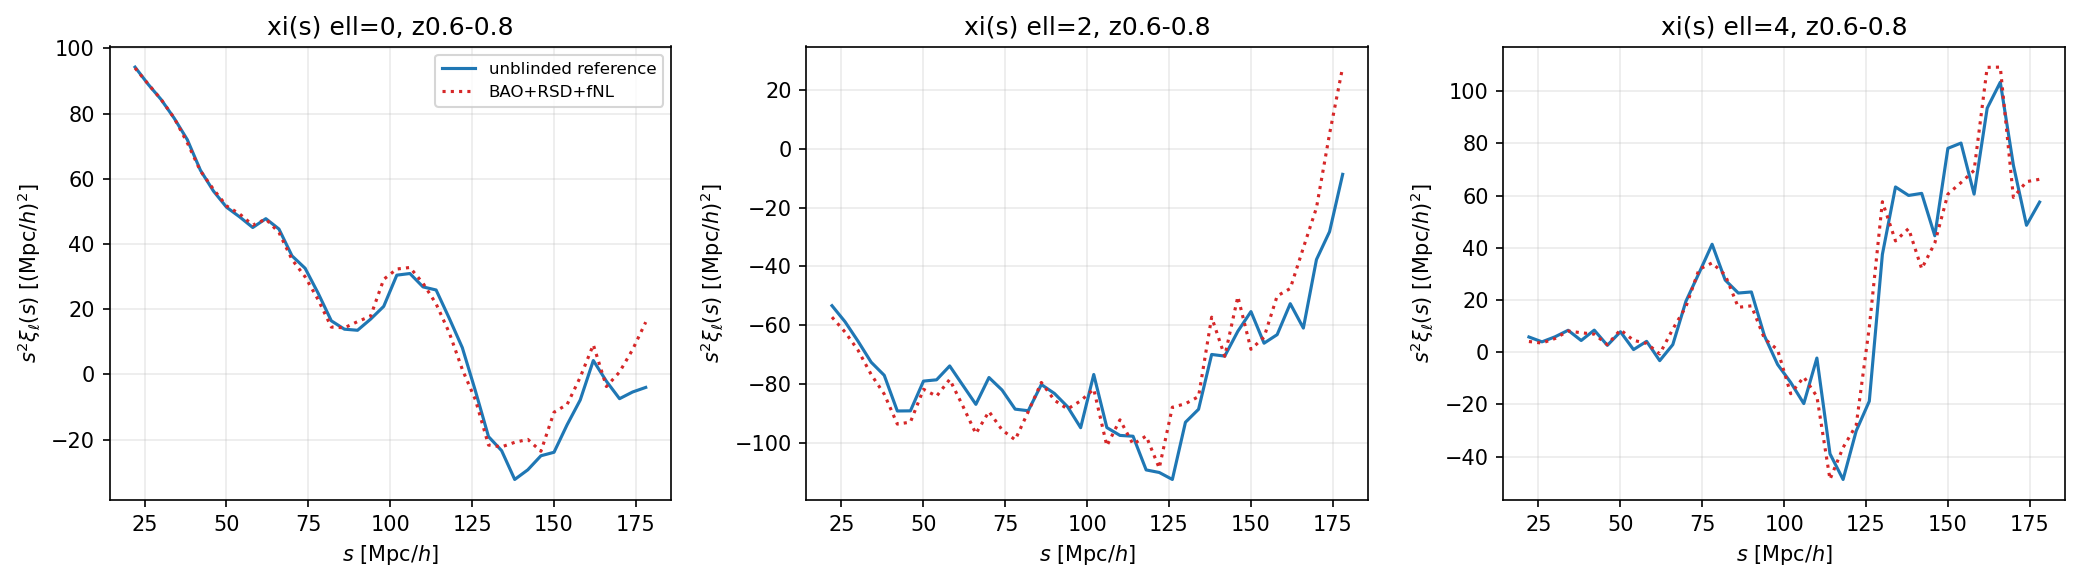

**mesh2_spectrum_unblind_bao_only_bao_rsd_bao_rsd_fnl_z0.6-0.8.png**

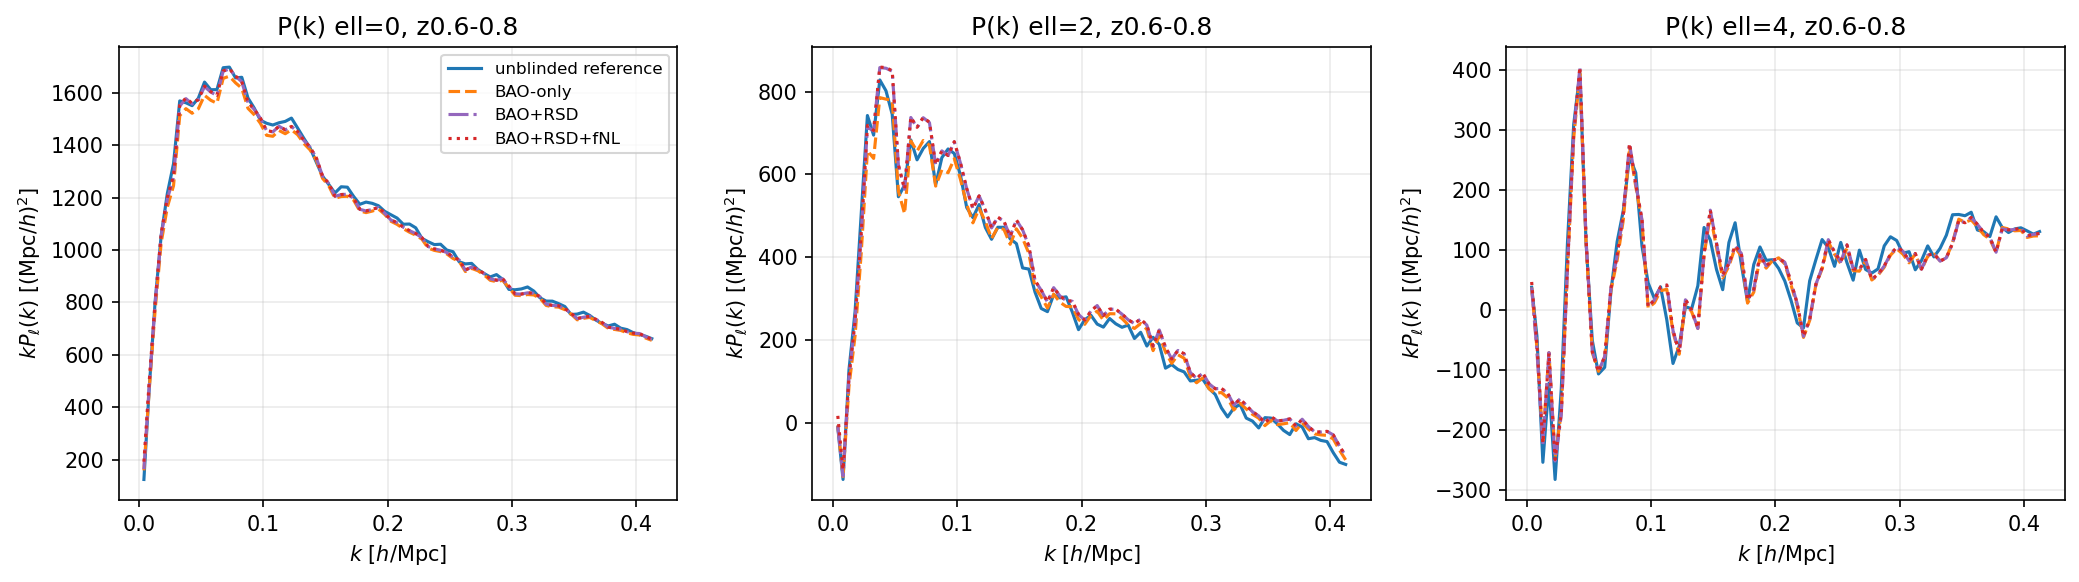

**particle2_correlation_unblind_bao_only_bao_rsd_bao_rsd_fnl_z0.6-0.8.png**

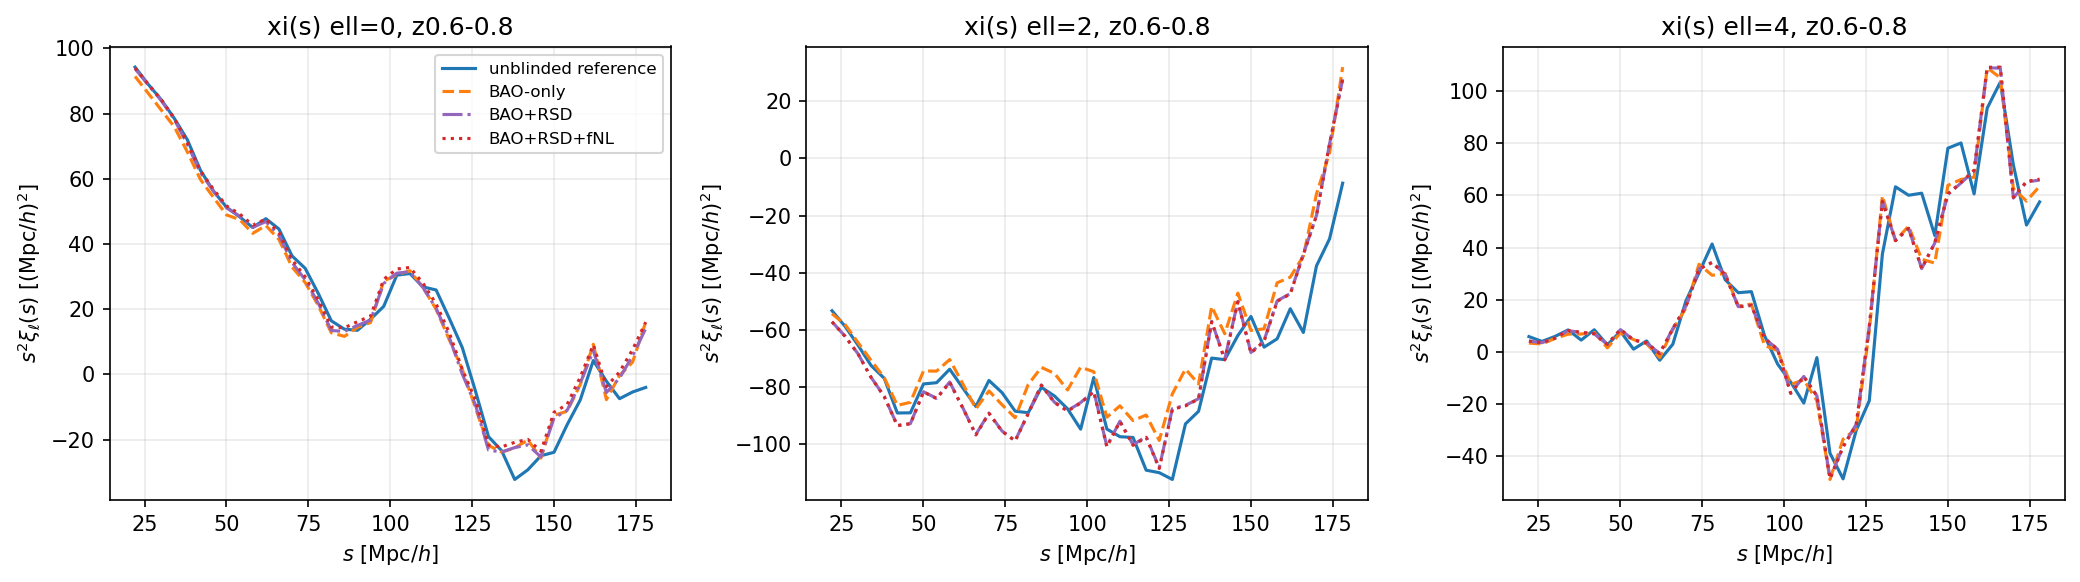

In [11]:
comparison_dir = COMBINED_ROOT / 'bao_rsd_fnl' / 'comparisons'
plot_names = [
    'mesh2_spectrum_unblind_vs_bao_only_z0.6-0.8.png',
    'particle2_correlation_unblind_vs_bao_only_z0.6-0.8.png',
    'mesh2_spectrum_unblind_vs_bao_rsd_z0.6-0.8.png',
    'particle2_correlation_unblind_vs_bao_rsd_z0.6-0.8.png',
    'mesh2_spectrum_unblind_vs_bao_rsd_fnl_z0.6-0.8.png',
    'particle2_correlation_unblind_vs_bao_rsd_fnl_z0.6-0.8.png',
    'mesh2_spectrum_unblind_bao_only_bao_rsd_bao_rsd_fnl_z0.6-0.8.png',
    'particle2_correlation_unblind_bao_only_bao_rsd_bao_rsd_fnl_z0.6-0.8.png',
]
for name in plot_names:
    path = comparison_dir / name
    assert path.exists(), path
    display(Markdown(f'**{name}**'))
    display(Image(filename=str(path)))


## Summary

The current fNL validation status is:

- `CatalogFNLBlinder` exactly reproduces the LSS core `mockfactory` fNL operation for `method='data_weights'` and `shotnoise_correction=True`.
- The `desi-clustering` saved-catalog driver applies fNL after BAO/RSD and before final random resampling / nbar / FKP rebuild.
- Saved fNL catalogs do not write a blinding-specific weight-ratio column; the fNL factor is internal/diagnostic.
- Full-row LRG NGC saved-catalog checks pass for fNL-only and `BAO+RSD+fNL`.
- Reduced Pk/xi measurements exist for the matched unblinded reference, BAO-only, BAO+RSD, and BAO+RSD+fNL states and are overplotted above.

Caveat: these are fresh full end-to-end LRG NGC nran=2 validation products. They verify the implementation path and plumbing, not a full-science fNL response on production statistics.
